In [1]:
from numba import cuda

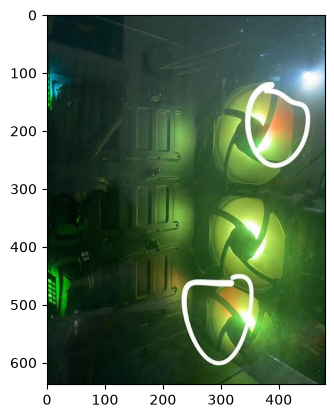

In [15]:
import matplotlib.pyplot as plt

image = plt.imread('1.jpeg')
plt.imshow(image)
h, w, d = image.shape

0.16460418701171875


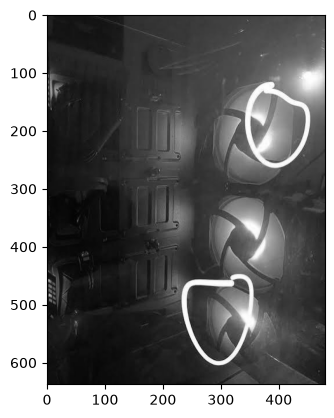

In [16]:
import math
import time
import numpy as np
@cuda.jit
def grayscale2D(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
    dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

blockSize = (32, 32)
gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))

start_gpu = time.time()
devSrc = cuda.to_device(image)
devDst = cuda.device_array((h, w, 3), np.uint8)
grayscale2D[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()
end_gpu = time.time() - start_gpu
print(end_gpu)
plt.imshow(hostDst)

In [14]:
grayCPU = np.zeros((h, w), np.uint8)
start = time.time()
for y in range(h):
    for x in range(w):
        grayCPU[y, x] = np.uint8((int(image[y, x, 0]) + int(image[y, x, 1]) + int(image[y, x, 2])) / 3)
cpu_time = time.time() - start
cpu_time

0.31050825119018555

Block size: (4, 4)
Grid size: (120, 160)
GPU time: 0.013178348541259766 seconds
Block size: (8, 8)
Grid size: (60, 80)
GPU time: 0.00021719932556152344 seconds
Block size: (16, 16)
Grid size: (30, 40)
GPU time: 0.00014734268188476562 seconds
Block size: (32, 32)
Grid size: (15, 20)
GPU time: 0.00012922286987304688 seconds


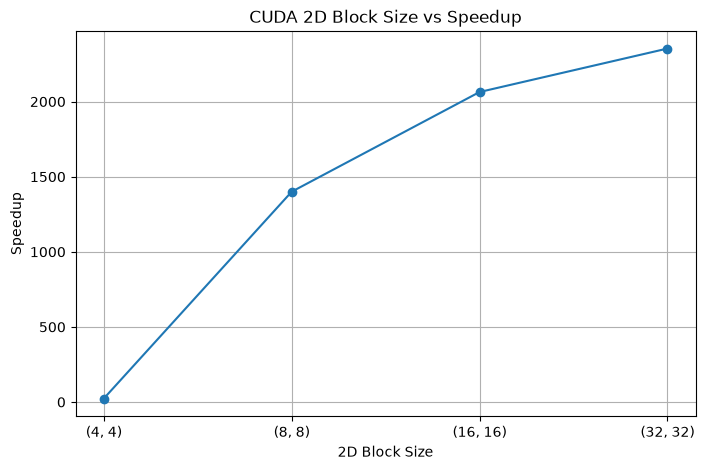

In [13]:
block_sizes = [(4, 4), (8, 8), (16, 16), (32, 32)]
speedups = []

for blockSize in block_sizes:
    gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
    devDst = cuda.device_array((h, w, 3), dtype=np.uint8)
    start = time.time()
    grayscale2D[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()
    end = time.time()
    gpu_time = end - start
    speedups.append(cpu_time / gpu_time)

    print(f"Block size: {blockSize}")
    print(f"Grid size: {gridSize}")
    print(f"GPU time: {gpu_time} seconds")

plt.figure(figsize=(8, 5))
plt.plot([str(b) for b in block_sizes], speedups, marker='o')
plt.xlabel("2D Block Size")
plt.ylabel("Speedup")
plt.title("CUDA 2D Block Size vs Speedup")
plt.grid(True)
plt.show()